In [1]:
import numpy as np
from plot_module.UVVIS_analyzer import UV_VIS_Analyzer
from plot_module.Spectra import Spectroscopy
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression

In [2]:
analyzer = UV_VIS_Analyzer(folderPath="", tauc=True)  # Enter your file path/folder path in this place

FileNotFoundError: [Errno 2] No such file or directory: ""  # Enter your file path/folder path in this place

Import Dark, light and T data:

In [ ]:
darkFile = ""  # Enter your file path/folder path in this place
lightFile = ""  # Enter your file path/folder path in this place
data25 = ""  # Enter your file path/folder path in this place
data50 = ""  # Enter your file path/folder path in this place

dark = pd.read_csv(darkFile, decimal=",", sep=";")
light = pd.read_csv(lightFile, decimal=",", sep=";")
cpi50 = pd.read_csv(data50, decimal=",", sep=";")
cpi25 = pd.read_csv(data25, decimal=",", sep=";")
darkData = dark.values.T
lightData = light.values.T
cpi25Data = cpi25.values.T
cpi50Data = cpi50.values.T


In [ ]:
wavelength = cpi25Data[0]
eV = 1250 / wavelength
cpi25Data_calibrated = [cpi25Data[0], cpi25Data[1]-darkData[1]]
cpi50Data_calibrated = [cpi50Data[0], cpi50Data[1]-darkData[1]]
lightData_calibrated = [lightData[0], lightData[1]-darkData[1]]
cpi25_trans = cpi25Data_calibrated[1] / lightData_calibrated[1]
cpi50_trans = cpi50Data_calibrated[1] / lightData_calibrated[1]
cpi25_abs = - np.log10(cpi25_trans)
cpi50_abs = - np.log10(cpi50_trans)
cpi25_tauc = (cpi25_abs * eV) ** 2
cpi50_tauc = (cpi50_abs * eV) ** 2

/var/folders/gk/j7sbhfc93v5gxyqp6ltt1dqc0000gn/T/ipykernel_41654/2770137332.py:8: RuntimeWarning: invalid value encountered in log10
  cpi25_abs = - np.log10(cpi25_trans)
/var/folders/gk/j7sbhfc93v5gxyqp6ltt1dqc0000gn/T/ipykernel_41654/2770137332.py:9: RuntimeWarning: invalid value encountered in log10
  cpi50_abs = - np.log10(cpi50_trans)


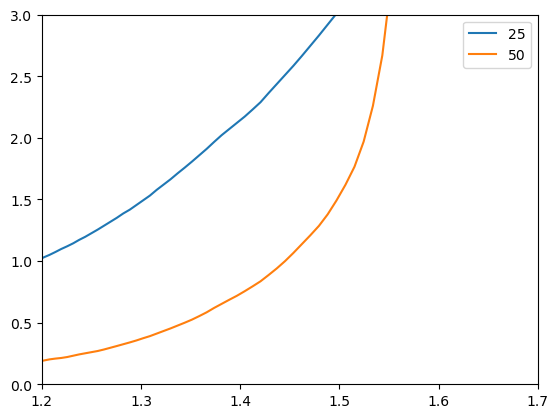

In [ ]:
plt.figure()
plt.plot(eV, cpi25_tauc, label = "25")
plt.plot(eV, cpi50_tauc, label = "50")
plt.xlim(1.2, 1.7)
plt.ylim(0, 3)
plt.legend()

In [ ]:
mask25 = (eV >= 1.55) & (eV <= 1.6)
cpi25_tauc_mask = cpi25_tauc[mask25]
cpi50_tauc_mask = cpi50_tauc[mask25]
eV_mask = eV[mask25]
model25 = LinearRegression()
model25.fit(eV_mask.reshape(-1, 1), cpi25_tauc_mask.reshape(-1, 1))
b25 = model25.intercept_[0] #This is the intercept with the y-axis!
slope25 = model25.coef_[0] #This is the x-axis!
#print("b:", b, "slope:", slope, self.labels[i]) #
intercept25 = model25.intercept_
x_intercept25 = - intercept25 / slope25 #Intercept with x axis

model50 = LinearRegression()
model50.fit(eV_mask.reshape(-1, 1), cpi50_tauc_mask.reshape(-1, 1))
b50 = model50.intercept_[0] #This is the intercept with the y-axis!
slope50 = model50.coef_[0] #This is the x-axis!
#print("b:", b, "slope:", slope, self.labels[i]) #
intercept50 = model50.intercept_
x_intercept50 = - intercept50 / slope50 #Intercept with x axis


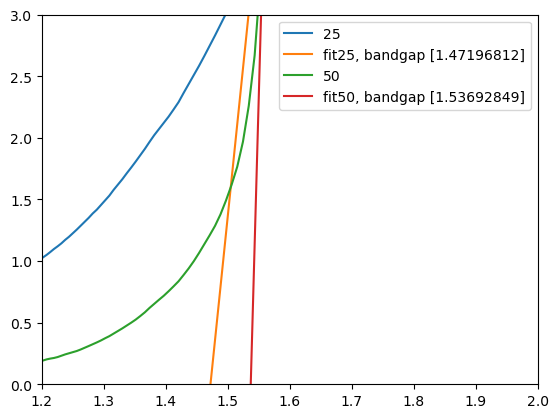

In [ ]:
plt.figure()
plt.plot(eV, cpi25_tauc, label = "25")
plt.plot(eV, b25 + slope25 * eV, label = f"fit25, bandgap {x_intercept25}")
plt.plot(eV, cpi50_tauc, label = "50")
plt.plot(eV, b50 + slope50 * eV, label = f"fit50, bandgap {x_intercept50}")
plt.xlim(1.2, 2)
plt.ylim(0, 3)
plt.legend()

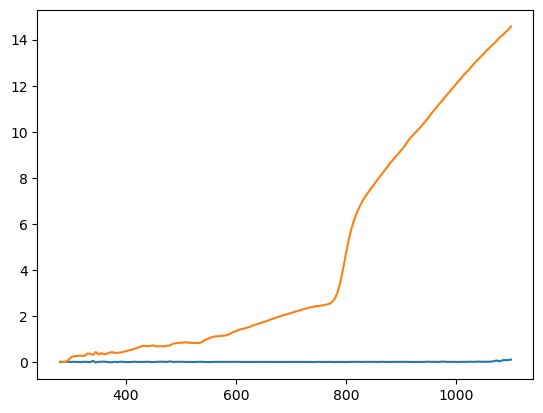

In [ ]:
plt.figure()
plt.plot(darkData[0], darkData[1])
plt.plot(cpi25Data[0], cpi25Data[1])

In [ ]:
print(DarkData_np)

[[104000]
 [ 78000]
 [ 81000]
 [ 75000]
 [ 25000]
 [ 62000]
 [ 42000]
 [ 15000]
 [  8000]
 [ 11000]
 [ 11000]
 [  5000]
 [ 17000]
 [  4000]
 [  9000]
 [  9000]
 [  7000]
 [  2000]
 [  6000]
 [     0]
 [  1000]
 [  2000]
 [  2000]
 [  1000]
 [  7000]
 [ 18000]
 [  3000]
 [  5000]
 [  6000]
 [  2000]
 [ 11000]
 [  7000]
 [     0]
 [  4000]
 [     0]
 [  2000]
 [  2000]
 [  2000]
 [  4000]
 [  6000]
 [  5000]
 [  5000]
 [  2000]
 [  2000]
 [  2000]
 [     0]
 [  2000]
 [  6000]
 [  1000]
 [  1000]
 [  4000]
 [  3000]
 [  6000]
 [  3000]
 [     0]
 [  4000]
 [  6000]
 [  3000]
 [  4000]
 [  2000]
 [  3000]
 [  3000]
 [  2000]
 [  3000]
 [  4000]
 [  1000]
 [  3000]
 [     0]
 [  2000]
 [  1000]
 [  5000]
 [  3000]
 [  1000]
 [  2000]
 [     0]
 [  2000]
 [  3000]
 [     0]
 [  2000]
 [  2000]
 [  1000]
 [  4000]
 [     0]
 [  1000]
 [  4000]
 [  1000]
 [     0]
 [  3000]
 [     0]
 [  4000]
 [  1000]
 [  3000]
 [  4000]
 [  3000]
 [  1000]
 [     0]
 [  1000]
 [  1000]
 [  2000]
 [  5000]
